### Feature Encoding

Categorical variables were converted into numerical format in the data wrangling stage. This includes:

- Room type variables encoded using one-hot encoding (e.g., hotel room, private room, shared room)
- Amenities transformed into binary indicator variables (e.g., amenity_wifi, amenity_pool)

As a result, all features used in the modeling stage are already in a machine-readable numeric format, and no additional encoding was required in this step.

### Problem framing
* The goal of this notebook is to build and compare machine learning models that predict Airbnb listing demand. For this project, I am using `reviews_per_month` as a proxy for demand since booking data is not public. Since `reviews_per_month` is a continuous numeric variable, this is a regression problem.The target variable is log-transformed using `np.log1p()` to reduce skew  and make the model less sensitive to extreme values (many listings have 0 reviews).
* I am predicting log reviews per month as a proxy for demand.
* End goal: Given a location, what combination of features maximizes consistent demand (and reasonable price)?
### Define target and features
* Core listing features
* Amenity features
Explain why rare/common amenities were filtered
### Train/test split
* Confirm this is not time-series forecasting, so random split is acceptable.
### Baseline model
* Linear Regression
* MAE, RMSE, R²
### Regularized linear models
* Ridge
* Lasso
* Explain: helps with correlated features and feature shrinkage.
### Nonlinear models
* Random Forest
* XGBoost
### Cross-validation
* Compare average performance across folds.
### Hyperparameter tuning
* Tune Random Forest and/or XGBoost.
### Final model selection
* Choose the best model based on performance and explainability.
### Stakeholder interpretation
* The model suggests that demand is most strongly associated with capacity, location, review quality, and select amenities.

### Modeling Strategy

* dummy classifier
* 

<b>Step 1: Build interpretable baseline linear model</b>
   * Linear Regression
   * Establish baseline performance
   * Understand directional relationships
   * Interpret coefficients


<b>Step 2: Address multicollinearity / overfitting</b>
   * Ridge / Lasso Regression
   * Improve generalization of linear model
   * Reduce impact of correlated features
   * Perform feature shrinkage/selection


<b>Step 3: Compare against nonlinear ensemble model</b> 
   * Random Forest Regressor
   * Capture nonlinear relationships
   * Capture feature interactions automatically
   * Estimate relative feature importance


<b>Step 4: Test advanced boosting model </b> 
   * XGBoost / Gradient Boosting
   * Optimize predictive performance
   * Compare against Random Forest benchmark
   * Assess marginal gains vs complexity

<b>Step 5: Evaluate tradeoffs</b>
   * Compare all model metrics
   * Balance interpretability vs predictive power
   * Determine which metrics to use
   * Select final recommended model
   * Confusion Matrix
   * Precision
   * Recall
   * F1-score
   * ROC-AUC

### Questions to answer: 
Linear Models Will Help Answer:
* How much does an amenity independently impact nightly price?
* How much additional price is associated with each bedroom/bathroom?
* Is superhost status predictive when other listing characteristics are controlled?

Tree Models Will Help Answer:
* Are there nonlinear pricing thresholds? (do prices skyrocket or plateau at a certain point?)
* Do amenities interact to create compounded pricing effects? 
* Which features are most influential overall in price prediction?

General notes / Questions (not for capstone):
Apriori / FP-Growth for amenities
Amenity bundling insights
Market segmentation
Design/package recommendations

Genetic Algorithms
Airbnb Optimization

Find best amenity package:

Given budget $15k, which upgrades maximize ADR
Optimize renovation package combinations:

Which improvements maximize ROI under budget?

Notes: In the above example of real estate price estimation, it seems difficult to predict the exact price of a real estate. However, if we reformulate the problem as predicting the price range of real estate instead of a single price tag, then we could expect to obtain a more robust model. As a result, we transform the problem into a classification problem, instead of regression.

most helpful analogy: The more stable the performance of a learner, the less its variance. In the game of dart, a learner with high variance corresponds to a lousy player who rarely lands the dart in the same place. On the other hand, a learner with low variance could correspond to a decent player who rarely misses the bullseye.



### THINGS TO TRY
* Let's test different models
* hyperparameter tuning
* model performance evaluation
* using pipelines
* We can easily compute the relative frequencies (percentages) to better quantify differences in the incidences of the classes: class_percentages = pd.Series([(x / dflog.shape[0]) * 100.00 for x in class_counts])
class_percentages (but using applicable code/df)
* Now we can use the percentages as labels and plot the distribution of the two classes:
* 

There are two important challenges posed by ICPs:

The difference in the size of the classes is inherent to the problem under study. This means that one cannot pave this difference by adding more elements to the minority class.

Classification algorithms are usually negatively affected by the lack of sufficient samples of the minority class, in that the models built with them are practically unable to differentiate the minority class from the majority class, where the former is the one of interest. For instance, imagine a model built to compute the likelihod of a patient developing Cancer that nearly always predicts a small likelihood for this class (meaning, that the model predicts NO Cancer, when it should have predicted Cancer in some cases).

Do we need to run a confusion matrix for this? 


## Resources
https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-machine-learning-tips-and-tricks/



## Imports 

In [1]:
!pip install xgboost

In [2]:
# Core tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Train/test split, cross-validation, and tuning
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Clean Data

In [3]:
# Load cleaned Airbnb data
df = pd.read_csv('../data/processed/airbnb_preprocessed.csv')

## Inspect Dataset

In [4]:
df.shape

(266350, 85)

In [5]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type,rating_bin,lat_bin,lon_bin
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"


In [6]:
df.columns.tolist()

['id',
 'host_id',
 'room_type_hotel_room',
 'room_type_private_room',
 'room_type_shared_room',
 'accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'host_is_superhost',
 'host_response_time_ord',
 'price',
 'latitude',
 'longitude',
 'number_of_reviews',
 'reviews_per_month',
 'review_scores_rating',
 'instant_bookable',
 'amenity_air_conditioning',
 'amenity_bathtub',
 'amenity_bbq_grill',
 'amenity_beach_access',
 'amenity_bed_linens',
 'amenity_blender',
 'amenity_carbon_monoxide_alarm',
 'amenity_cleaning_supplies',
 'amenity_coffee_maker',
 'amenity_cooking_basics',
 'amenity_dishwasher',
 'amenity_dryer',
 'amenity_essentials',
 'amenity_ev_charger',
 'amenity_fan',
 'amenity_fire_extinguisher',
 'amenity_fireplace',
 'amenity_first_aid_kit',
 'amenity_flexible_checkin',
 'amenity_game_console',
 'amenity_gym',
 'amenity_hair_dryer',
 'amenity_hangers',
 'amenity_heating',
 'amenity_host_services',
 'amenity_hot_tub',
 'amenity_hot_water',
 'amenity_iron',
 'amenity_kids_ameni

## Exploring 'Reviews per Month'

In [7]:
df['reviews_per_month'].describe()

count    266350.000000
mean          1.277646
std           1.786097
min           0.000000
25%           0.050000
50%           0.580000
75%           1.960000
max         101.420000
Name: reviews_per_month, dtype: float64

In [8]:
# Check how many listings have 0 reviews per month
zero_count = (df['reviews_per_month'] == 0).sum()
zero_percent = (df['reviews_per_month'] == 0).mean() * 100

print("Listings with 0 reviews_per_month:", zero_count)
print("Percent with 0 reviews_per_month:", round(zero_percent, 2), "%")

Listings with 0 reviews_per_month: 55356
Percent with 0 reviews_per_month: 20.78 %


In [9]:
# Find the 95th percentile for reviews_per_month
reviews_95 = df['reviews_per_month'].quantile(0.95)

print("95th percentile for reviews_per_month:", reviews_95)

reviews_95_count = (df['reviews_per_month'] > reviews_95).sum()
reviews_95_percent = (df['reviews_per_month'] > reviews_95).mean() * 100

print("Listings with high reviews_per_month:", reviews_95_count)
print("Percent with high reviews_per_month:", round(reviews_95_percent, 2), "%")

95th percentile for reviews_per_month: 4.59
Listings with high reviews_per_month: 13239
Percent with high reviews_per_month: 4.97 %


In [10]:
# Inspect listings with unusually high reviews_per_month
# These may be data errors, duplicated listings, or listings with unusual review activity.

high_review_listings = df[df['reviews_per_month'] > 50].copy()

# Check how many listings are above 50 reviews per month
print("Listings with reviews_per_month > 50:", high_review_listings.shape[0])

Listings with reviews_per_month > 50: 14


In [11]:
# Key columns for review - determine if these should just be removed from the dataset
high_review_listings[
    [
        'id',
        'host_id',
        'city',
        'room_type',
        'price',
        'reviews_per_month',
        'number_of_reviews',
        'review_scores_rating',
        'host_is_superhost',
        'instant_bookable']].sort_values(by='reviews_per_month', ascending=False)

,id,host_id,city,room_type,price,reviews_per_month,number_of_reviews,review_scores_rating,host_is_superhost,instant_bookable
46131,35159128,263748930,Clark County,Private room,228.0,101.42,1146,4.67,0.0,1
150965,54227245,438770271,Nashville,Entire home/apt,117.0,99.19,1425,4.88,1.0,1
168335,53843545,435369966,Nyc,Private room,213.0,86.61,1097,4.45,0.0,1
118229,578174478591578178,253105222,Los Angeles,Private room,132.0,81.19,977,4.29,0.0,0
46110,35158303,263748930,Clark County,Private room,226.0,68.66,1705,4.50,0.0,1
170464,44799007,219517861,Nyc,Entire home/apt,234.0,61.26,1842,4.72,0.0,0
122179,53827863,253105222,Los Angeles,Private room,133.0,59.73,880,4.36,0.0,0
260425,659366271388568374,459231442,Washington Dc,Entire home/apt,733.0,59.65,517,4.36,0.0,1
157830,565317486488599327,218602737,New Orleans,Entire home/apt,379.0,58.48,733,4.46,0.0,0
37502,29819757,57387860,Chicago,Hotel room,173.0,58.47,3091,4.52,0.0,1


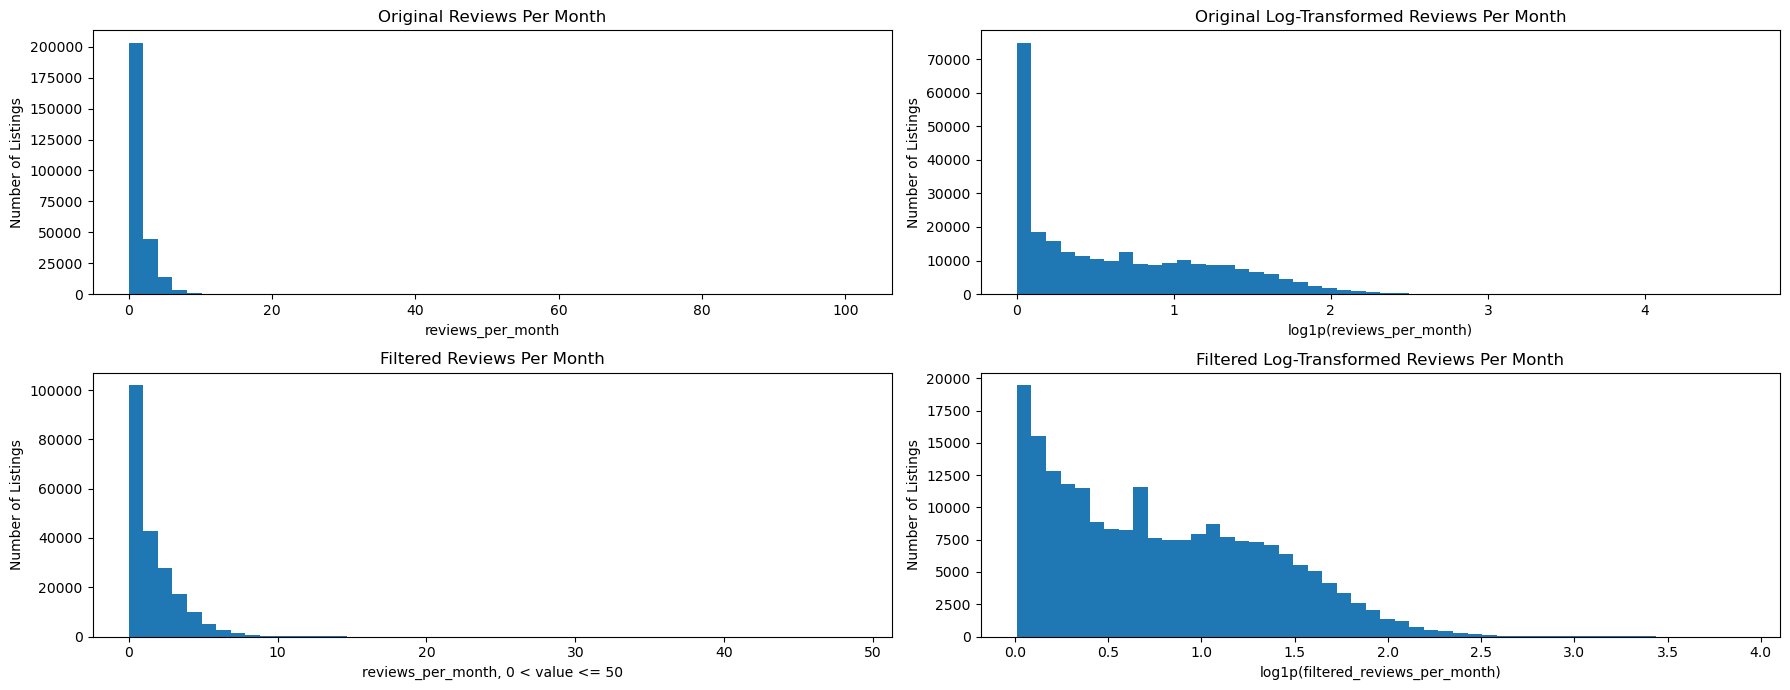

In [12]:
# Compare original, original log-transformed, filtered, and filtered log-transformed reviews_per_month

# Create filtered reviews: remove 0 values and values above 50 (extreme outliers)
filtered_reviews = df[
    (df['reviews_per_month'] > 0) &
    (df['reviews_per_month'] <= 50)]['reviews_per_month']

fig, axes = plt.subplots(2, 2, figsize=(18,7))

# 1. Original reviews_per_month
axes[0, 0].hist(df['reviews_per_month'], bins=50)
axes[0, 0].set_title('Original Reviews Per Month')
axes[0, 0].set_xlabel('reviews_per_month')
axes[0, 0].set_ylabel('Number of Listings')

# 2. Original log-transformed reviews_per_month
axes[0, 1].hist(np.log1p(df['reviews_per_month']), bins=50)
axes[0, 1].set_title('Original Log-Transformed Reviews Per Month')
axes[0, 1].set_xlabel('log1p(reviews_per_month)')
axes[0, 1].set_ylabel('Number of Listings')

# 3. Filtered reviews_per_month
axes[1, 0].hist(filtered_reviews, bins=50)
axes[1, 0].set_title('Filtered Reviews Per Month')
axes[1, 0].set_xlabel('reviews_per_month, 0 < value <= 50')
axes[1, 0].set_ylabel('Number of Listings')

# 4. Filtered log-transformed reviews_per_month
axes[1, 1].hist(np.log1p(filtered_reviews), bins=50)
axes[1, 1].set_title('Filtered Log-Transformed Reviews Per Month')
axes[1, 1].set_xlabel('log1p(filtered_reviews_per_month)')
axes[1, 1].set_ylabel('Number of Listings')

plt.tight_layout()
plt.show()

## Define Target

The target variable for this model is `reviews_per_month`, which is being used as a proxy for listing demand.

The original distribution was right-skewed. Many listings had zero reviews per month, while a small number of listings had unusually high values. The median was only 0.58 reviews per month, but the maximum was over 100 reviews per month.

Before modeling, I filtered the dataset to include only active listings with observed review activity:

- Removed listings with `reviews_per_month` equal to 0
- Removed listings with more than 50 reviews per month

The upper cutoff of 50 reviews per month is intentionally conservative. It removes the most extreme values while keeping high-performing listings in the dataset. This helps reduce the influence of inactive listings and inflated review activity, especially from hotel-style or multi-room listings where review count may overstate true booking demand (based on manual review of listings).

After filtering, I applied a log transformation using `np.log1p()` because the target variable remained right-skewed.

In [13]:
# Filter dataframe for modeling
# Remove listings with no review activity and extreme reviews_per_month values above 50

df = df[
    (df['reviews_per_month'] > 0) &
    (df['reviews_per_month'] <= 50)].copy()

# Create log-transformed target
df['reviews_per_month_log'] = np.log1p(df['reviews_per_month'])

# Define target variable
y = df['reviews_per_month_log']

In [14]:
# Check target summary
y.describe()

count    210980.000000
mean          0.783635
std           0.568907
min           0.009950
25%           0.270027
50%           0.693147
75%           1.214913
max           3.908417
Name: reviews_per_month_log, dtype: float64

In [15]:
df.shape

(210980, 86)

## Select Features
The first model uses a small set of core features to create a baseline model before adding amenity features.

It includes capacity, location, host status, booking type, and review score.

In [16]:
# Select core listing features (baseline model)
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'instant_bookable',
    'review_scores_rating']

# Define baseline feature matrix
X = df[features]

# Preview features
X.head()

,accommodates,bedrooms,beds,bathrooms,latitude,longitude,host_is_superhost,instant_bookable,review_scores_rating
0,2,1.0,1.0,1.0,35.60670,-82.55563,1.0,0,4.51
1,2,1.0,1.0,1.0,35.57864,-82.59578,0.0,0,4.59
2,2,1.0,1.0,2.5,35.57864,-82.59578,0.0,1,4.52
3,2,1.0,1.0,1.0,35.57808,-82.63689,1.0,0,4.95
4,4,1.0,2.0,1.0,35.61856,-82.55276,1.0,0,4.87


## Train/test split
The data was split into training and testing sets using an 80/20 split.

Since this project is not a time series or forecasting problem, a random train/test split works.

In [17]:
# Split baseline data into training and testing sets
# 80% of the data is used for training, 20% is held out for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Evaluation Function

To compare models consistently, I created a function that fits each model, makes predictions, and returns the same evaluation metrics.

The main metrics are:

* MAE: average prediction error (best for stakeholders)
* RMSE: average error with larger mistakes penalized more
* R²: variation explained by the model

In [18]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Fits a regression model, generates predictions, and calculates performance metrics.

    Parameters:
    model: The regression model or pipeline being tested.
    X_train: Training feature set.
    X_test: Testing feature set.
    y_train: Training target values.
    y_test: Testing target values.
    model_name: Name of the model for the results table.

    Returns:
    A dictionary containing model name, MAE, RMSE, and R².
    """
    
    # Fit model on training data
    model.fit(X_train, y_train)
    
    # Generate predictions on test data
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    # Print results
    print(f"{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    
    # Return results for comparison table
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2}

## Baseline Linear Regression

The baseline model uses Linear Regression with only the core listing features.

It's a starting point; I will later see if other models perform better, and how amenity features affect bookings.

In [19]:
# Create baseline linear regression model
baseline_model = LinearRegression()

# Evaluate baseline model using defined function: evaluate_regression_model
baseline_results = evaluate_regression_model(
    baseline_model, X_train, X_test, y_train, y_test, "Baseline Linear Regression")

Baseline Linear Regression
MAE: 0.43515592056172747
RMSE: 0.5272775059322873
R²: 0.14440239455089687


## Interpretation:

* The baseline model explains about 14.4% of the variation in log-transformed reviews per month.
* This suggests that core listing features have some predictive value, but they do not fully explain listing demand.
* The MAE is about 0.44 on the log-transformed target scale, meaning the model has a moderate average prediction error.
* Next step: add amenity features and test more flexible models to see whether they improve predictive performance.

## Handle Amenity Features

Amenities could impact demand because they signal quality, convenience, experience, or guest expectations.

However, extremely common amenities may add little value because almost every listing has them (wifi, smoke detectors, etc).  Extremely rare amenities may also be less useful because there are too few examples for the model to learn from (ski access, EV chargers).

To reduce noise, I kept amenities that appear in more than 5% and less than 95% of listings.

In [20]:
# Identify amenity columns
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

# Check amenity frequency
amenity_frequency = df[amenity_cols].mean().sort_values(ascending=False)

# View 20 most common amenities
amenity_frequency.head(10)

amenity_wifi                0.986980
amenity_smoke_alarm         0.950673
amenity_essentials          0.916570
amenity_kitchen             0.902943
amenity_tv                  0.890696
amenity_air_conditioning    0.839098
amenity_hangers             0.837127
amenity_cooking_basics      0.829993
amenity_refrigerator        0.828989
amenity_hair_dryer          0.821533
dtype: float64

In [21]:
# Keep amenities that are not too rare and not too common
selected_amenities = amenity_frequency[
    (amenity_frequency > 0.05) & (amenity_frequency < 0.95)].index.tolist()

# Check how many amenities were selected
len(selected_amenities)

48

In [22]:
# View selected amenities
selected_amenities[:20]

['amenity_essentials',
 'amenity_kitchen',
 'amenity_tv',
 'amenity_air_conditioning',
 'amenity_hangers',
 'amenity_cooking_basics',
 'amenity_refrigerator',
 'amenity_hair_dryer',
 'amenity_heating',
 'amenity_hot_water',
 'amenity_parking_free',
 'amenity_toiletries',
 'amenity_iron',
 'amenity_carbon_monoxide_alarm',
 'amenity_coffee_maker',
 'amenity_microwave',
 'amenity_washer',
 'amenity_bed_linens',
 'amenity_dryer',
 'amenity_fire_extinguisher']

In [23]:
rare_amenities = amenity_frequency[(amenity_frequency < 0.05)].index.tolist()

rare_amenities

['amenity_view_water',
 'amenity_view_other',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

In [24]:
df.shape

(210980, 86)

### Analysis: 
I'm curious to see if these rare amenities are more common in specific cities, and if so, what the effect is on price/booking. I may look into this later. 

## Feature Set With Amenities

The second feature set adds selected amenity variables to the baseline listing features.

We can use the model to test whether amenities improve demand prediction beyond basic listing characteristics.

## Feature Relationships With Price, Reviews, Demand, and Rating

To better understand how listing features and amenities relate to key business outcomes, I created a correlation heatmap comparing selected features against price, total reviews, reviews per month, and review score.

This is used for interpretation and feature understanding only. `number_of_reviews`, `reviews_per_month`, and review-related variables should not be used as predictors in the demand model because they are too closely related to the target.

In [25]:
# Feature relationships with key listing outcomes
# This heatmap shows which features/amenities are most correlated with price,
# total reviews, reviews per month, and review scores.

# Define outcome columns
outcome_cols = [
    'price',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating']

# Keep only columns that exist in the dataframe
outcome_cols = [col for col in outcome_cols if col in df.columns]

# Define core feature columns
core_feature_cols = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'instant_bookable',
    'host_response_time_ord']

# Keep only core feature columns that exist
core_feature_cols = [col for col in core_feature_cols if col in df.columns]

# Select amenity columns
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

# Combine features for correlation analysis
feature_cols_for_corr = core_feature_cols + amenity_cols

# Calculate correlations between features and outcome columns
corr_analysis_df = df[feature_cols_for_corr + outcome_cols].copy()
corr_matrix_full = corr_analysis_df.corr(numeric_only=True)

# Keep only feature-to-outcome correlations
feature_outcome_corr = corr_matrix_full.loc[feature_cols_for_corr, outcome_cols]

# Select top features based on strongest absolute correlation with any outcome
top_features = (
    feature_outcome_corr.abs().max(axis=1).sort_values(ascending=False).head(25).index)

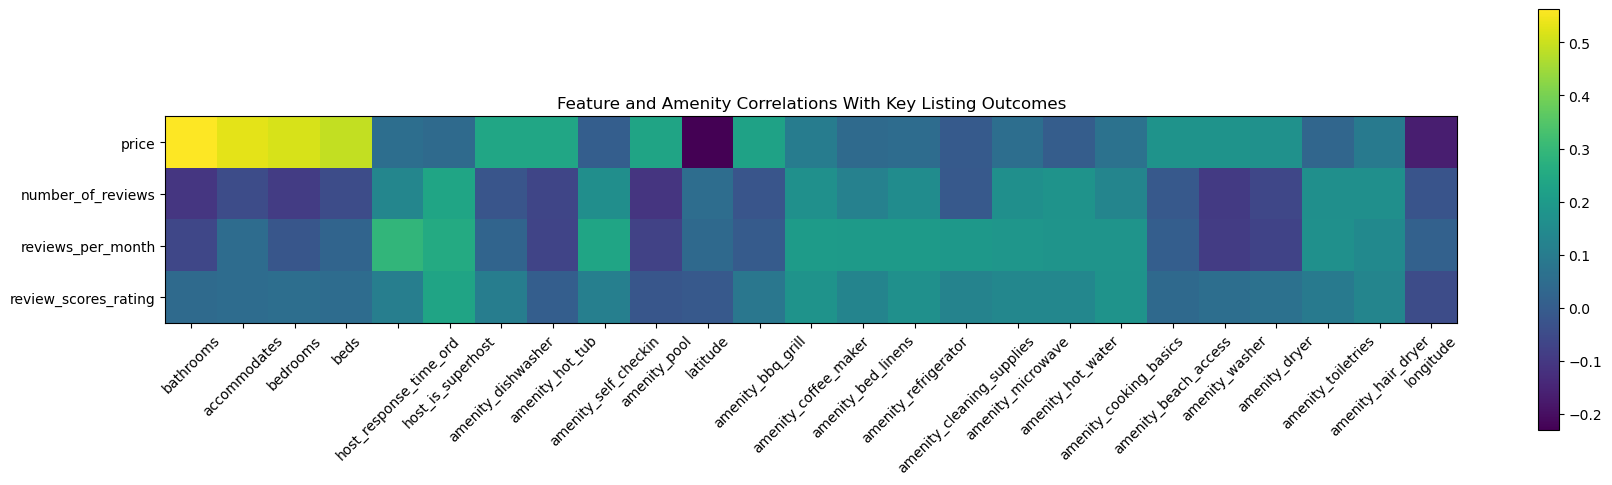

In [26]:
# Create heatmap matrix and transpose it so the chart is wider, not taller
heatmap_corr = feature_outcome_corr.loc[top_features, outcome_cols].T

# Plot wider heatmap
fig, ax = plt.subplots(figsize=(18, 5))

im = ax.imshow(heatmap_corr)

# Set axis labels
ax.set_xticks(range(len(heatmap_corr.columns)))
ax.set_yticks(range(len(heatmap_corr.index)))

ax.set_xticklabels(heatmap_corr.columns, rotation=45)
ax.set_yticklabels(heatmap_corr.index)

# Add colorbar and title
plt.colorbar(im, ax=ax)
ax.set_title('Feature and Amenity Correlations With Key Listing Outcomes')

plt.tight_layout()
plt.show()

## Linear Regression With Amenities

This model uses the same Linear Regression algorithm as the baseline model, but includes selected amenities.

The purpose is to test whether amenity features improve model performance.

In [27]:
# Combine baseline features with selected amenity features
features_with_amenities = features + selected_amenities

# Create expanded feature matrix
X2 = df[features_with_amenities]

# Use the same train/test split indexes as the baseline model
# This keeps model comparisons fair
X2_train = X2.loc[X_train.index]
X2_test = X2.loc[X_test.index]

# Confirm shapes
print("X2_train shape:", X2_train.shape)
print("X2_test shape:", X2_test.shape)

X2_train shape: (168784, 57)
X2_test shape: (42196, 57)


In [28]:
# Create linear regression model using expanded feature set
linear_amenity_model = LinearRegression()

# Evaluate model
linear_amenity_results = evaluate_regression_model(
    linear_amenity_model, X2_train, X2_test, y_train, y_test, "Linear Regression With Amenities")

Linear Regression With Amenities
MAE: 0.3843144896557024
RMSE: 0.4791218400528518
R²: 0.29354743287026575


## Ridge Regression Pipeline

Ridge Regression is a regularized linear model. It helps reduce overfitting by shrinking coefficients.

Because Ridge is sensitive to feature scale, I used a pipeline that first applies `StandardScaler`, then fits the Ridge model.

In [29]:
# Create Ridge pipeline
# Step 1: StandardScaler puts numeric features on the same scale
# Step 2: Ridge fits a regularized linear regression model
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))])

# Evaluate Ridge pipeline
ridge_results = evaluate_regression_model(
    ridge_pipeline, X2_train, X2_test, y_train, y_test, "Ridge Regression")

Ridge Regression
MAE: 0.38431463234921776
RMSE: 0.4791218565550661
R²: 0.2935473842061018


## Lasso Regression Pipeline

Lasso Regression is another regularized linear model. Unlike Ridge, Lasso can shrink some coefficients all the way to zero, which makes it useful for feature selection.

Because Lasso is also sensitive to feature scale, I used a pipeline with `StandardScaler` before the model.

In [30]:
# Create Lasso pipeline
# Step 1: StandardScaler puts numeric features on the same scale
# Step 2: Lasso fits a regularized model and may reduce some coefficients to zero
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.001, random_state=42, max_iter=10000))])

# Evaluate Lasso pipeline
lasso_results = evaluate_regression_model(
    lasso_pipeline, X2_train, X2_test, y_train, y_test,
    "Lasso Regression")

Lasso Regression
MAE: 0.3848602660741068
RMSE: 0.47926194032526276
R²: 0.2931342241230367


## Lasso Feature Selection

Because Lasso can reduce some coefficients to zero, I used it to identify which features were retained by the model.

This is not the final model decision by itself, but it helps interpret which variables may be contributing more useful signal.

In [31]:
# Fit Lasso pipeline so coefficients can be inspected
lasso_pipeline.fit(X2_train, y_train)

# Extract coefficients from the model step of the pipeline
lasso_coefficients = lasso_pipeline.named_steps['model'].coef_

# Create coefficient dataframe
lasso_coeffs = pd.DataFrame({
    'feature': X2.columns,
    'coefficient': lasso_coefficients})

# Keep non-zero coefficients
selected_features_lasso = lasso_coeffs[lasso_coeffs['coefficient'] != 0]

# Sort by absolute coefficient size
selected_features_lasso = selected_features_lasso.assign(
    abs_coefficient=selected_features_lasso['coefficient'].abs()
).sort_values(by='abs_coefficient', ascending=False)

# View top selected features
selected_features_lasso.head()

,feature,coefficient,abs_coefficient
0,accommodates,0.112099,0.112099
6,host_is_superhost,0.103750,0.103750
30,amenity_self_checkin,0.077453,0.077453
3,bathrooms,-0.055764,0.055764
40,amenity_cleaning_supplies,0.052415,0.052415


The Lasso model suggests that accommodates, superhost status, self-checkin, bathrooms, and cleaning supplies have the strongest linear associations with predicted demand.

Since we don't have direct booking data, these features only suggest demand rather than clear evidence of bookings.

## Random Forest Regressor

Random Forest is a nonlinear ensemble model that combines many decision trees.

This model is useful because it can capture nonlinear relationships and feature interactions between location, listing characteristics, amenities, and demand.

Unlike Ridge and Lasso, Random Forest does not require feature scaling.

In [33]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

# Evaluate Random Forest model
rf_results = evaluate_regression_model(
    rf_model, X2_train, X2_test, y_train, y_test, "Random Forest")

Random Forest
MAE: 0.3068732452553065
RMSE: 0.4009936485549563
R²: 0.5051585632194413


## Random Forest Feature Importance

Random Forest feature importance helps show which variables contributed most to the model's predictions.

This is useful for stakeholder interpretation because it connects the model results back to listing characteristics, location, and amenities.

In [34]:
# Fit Random Forest model
rf_model.fit(X2_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [35]:
# Create feature importance dataframe
rf_importance = pd.DataFrame({
    'feature': X2.columns,
    'importance': rf_model.feature_importances_})

# Sort by importance
rf_importance = rf_importance.sort_values(by='importance', ascending=False)

# View top 20 features
rf_importance.head(20)

,feature,importance
8,review_scores_rating,0.260435
5,longitude,0.107382
4,latitude,0.097935
6,host_is_superhost,0.043518
40,amenity_cleaning_supplies,0.041896
0,accommodates,0.035373
30,amenity_self_checkin,0.026886
2,beds,0.017491
7,instant_bookable,0.017290
3,bathrooms,0.017157


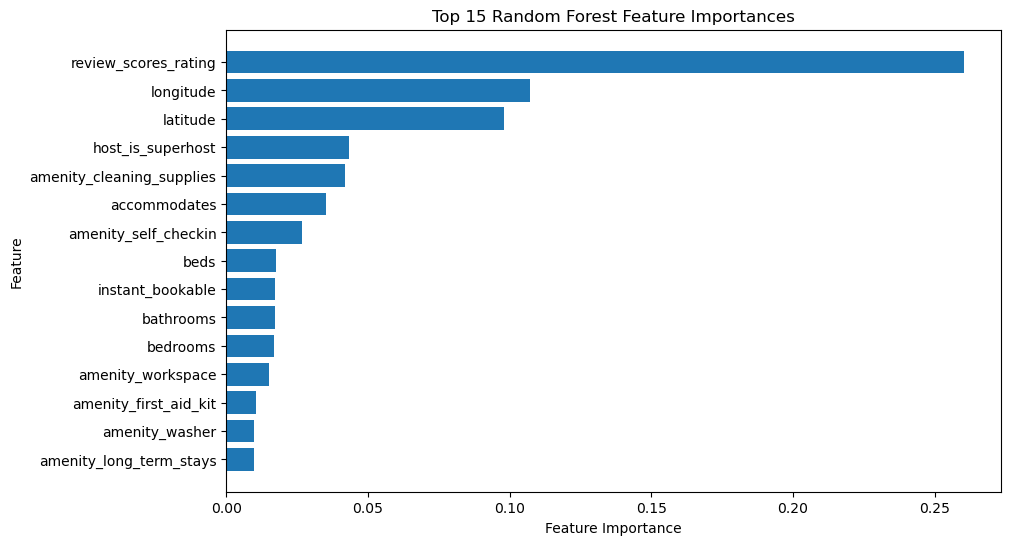

In [36]:
# Plot top 15 Random Forest feature importances
top_rf_features = rf_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_rf_features['feature'], top_rf_features['importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

## XGBoost Regressor

XGBoost is a boosted tree model. It builds trees sequentially, where each new tree tries to correct errors from the previous trees.

This model can perform very well on structured data, but it is more complex than Linear Regression or Random Forest.

Like Random Forest, XGBoost does not require feature scaling.

In [40]:
# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    objective='reg:squarederror')

In [41]:
# Evaluate XGBoost model
xgb_results = evaluate_regression_model(
    xgb_model, X2_train, X2_test, y_train, y_test, "XGBoost")

XGBoost
MAE: 0.309403316579326
RMSE: 0.40078460748852723
R²: 0.5056743580178327


In [42]:
df.shape

(210980, 86)

## Model Comparison

This table compares all regression models using the same test set.

For this project:

- Lower MAE is better
- Lower RMSE is better
- Higher R² is better

I am prioritizing RMSE and MAE because they directly measure prediction error. R² is helpful, but it should not be the only deciding metric.

In [43]:
# Combine all model results into one dataframe
model_results = [
    baseline_results, linear_amenity_results, ridge_results, lasso_results, rf_results, xgb_results]

model_comparison = pd.DataFrame(model_results)

# Sort models by RMSE
model_comparison.sort_values(by='RMSE')

,model,MAE,RMSE,R2
5,XGBoost,0.309403,0.400785,0.505674
4,Random Forest,0.306873,0.400994,0.505159
1,Linear Regression With Amenities,0.384314,0.479122,0.293547
2,Ridge Regression,0.384315,0.479122,0.293547
3,Lasso Regression,0.384860,0.479262,0.293134
0,Baseline Linear Regression,0.435156,0.527278,0.144402


## Cross-Validation

Cross-validation was used to check whether model performance is stable across multiple train/test splits.

Instead of judging each model based on one split, cross-validation trains and tests the model multiple times and returns the average performance.

This helps reduce the chance of selecting a model that only performed well because of a lucky train/test split.

In [44]:
# Create 5-fold cross-validation strategy
# This means each model will be trained/tested 5 different times.

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

In [45]:
def run_cross_validation(models, X, y, cv):
    """
    Runs cross-validation for multiple models and returns mean/std RMSE.
    """
    cv_results = []
    
    for name, model in models.items():
        print(f"Running cross-validation for: {name}")
        
        scores = cross_val_score(
            model, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
        
        rmse_scores = -scores
        
        cv_results.append({
            "model": name,
            "mean_cv_rmse": rmse_scores.mean(),
            "std_cv_rmse": rmse_scores.std()})
    
    return pd.DataFrame(cv_results).sort_values(by='mean_cv_rmse')

In [46]:
# Cross-validation for faster linear models

linear_cv_models = {
    "Linear Regression With Amenities": LinearRegression(),
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline}

linear_cv_results = run_cross_validation(
    linear_cv_models, X2, y, cv)

linear_cv_results

Running cross-validation for: Linear Regression With Amenities
Running cross-validation for: Ridge Regression
Running cross-validation for: Lasso Regression


,model,mean_cv_rmse,std_cv_rmse
1,Ridge Regression,0.479902,0.002836
0,Linear Regression With Amenities,0.479902,0.002836
2,Lasso Regression,0.479979,0.002813


In [47]:
# Cross-validation for slower tree-based models

tree_cv_models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model}

tree_cv_results = run_cross_validation(
    tree_cv_models, X2, y, cv)

tree_cv_results

Running cross-validation for: Random Forest
Running cross-validation for: XGBoost


,model,mean_cv_rmse,std_cv_rmse
0,Random Forest,0.398620,0.002780
1,XGBoost,0.399256,0.002449


In [48]:
# Combine cross-validation results

cv_results_df = pd.concat(
    [linear_cv_results, tree_cv_results],
    ignore_index=True).sort_values(by='mean_cv_rmse')

cv_results_df

,model,mean_cv_rmse,std_cv_rmse
3,Random Forest,0.398620,0.002780
4,XGBoost,0.399256,0.002449
0,Ridge Regression,0.479902,0.002836
1,Linear Regression With Amenities,0.479902,0.002836
2,Lasso Regression,0.479979,0.002813


The cross-validation results show that the tree-based models performed better than the linear models. Random Forest had the lowest average cross-validated RMSE, followed closely by XGBoost. The linear models performed almost identically, which suggests that regularization did not meaningfully improve performance.

Because Random Forest had the strongest average performance and is more interpretable than XGBoost, it is the strongest candidate for the final model.

Lower mean_cv_rmse is better.

## Hyperparameter Tuning

After comparing the initial models, I tuned the Random Forest model because it performed well and is easier to explain than XGBoost.

The goal of tuning is to test different model settings and identify a version that improves prediction performance without becoming unnecessarily complex.

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_param_grid_small = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid_small,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

best_rf = rf_grid_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Performance:")
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)
print("R²:", r2_rf_tuned)

Tuned Random Forest Performance:
RMSE: 0.4392024207760901
MAE: 0.3432182712608877
R²: 0.4063636009576833


To avoid unnecessary model complexity and long runtime, I used a smaller parameter grid with 3-fold cross-validation. This allowed me to test meaningful Random Forest settings while keeping the tuning process efficient and interpretable.

## Final Model Comparison

The tuned Random Forest model was added to the model comparison table to determine whether hyperparameter tuning improved performance.

In [51]:
best_rf_results = {
    'model': 'Tuned Random Forest',
    'MAE': mae_rf_tuned,
    'RMSE': rmse_rf_tuned,
    'R2': r2_rf_tuned
}

# Add tuned Random Forest to results
final_model_results = model_results + [best_rf_results]

# Create final comparison table
final_model_comparison = pd.DataFrame(final_model_results)

# Sort by RMSE
final_model_comparison.sort_values(by='RMSE')

,model,MAE,RMSE,R2
5,XGBoost,0.309403,0.400785,0.505674
4,Random Forest,0.306873,0.400994,0.505159
6,Tuned Random Forest,0.343218,0.439202,0.406364
1,Linear Regression With Amenities,0.384314,0.479122,0.293547
2,Ridge Regression,0.384315,0.479122,0.293547
3,Lasso Regression,0.384860,0.479262,0.293134
0,Baseline Linear Regression,0.435156,0.527278,0.144402


In [52]:
df.shape

(210980, 86)

## Final Model Selection

Based on the model comparison, cross-validation results, and interpretability, the final model selected for this project is the Random Forest Regressor.

The Random Forest model performed better than the linear models because it can capture nonlinear relationships and interactions between listing features, location, amenities, and demand.

Although XGBoost may also perform strongly, Random Forest offers a strong balance between predictive performance and interpretability. This matters because the goal of the project is not only to predict demand, but also to understand which features are associated with stronger listing performance.

## Final Model Feature Importance

After selecting the final model, I reviewed feature importance to identify which listing characteristics were most associated with predicted demand.

In [53]:
# Create feature importance dataframe from tuned Random Forest model
tuned_rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_})

tuned_rf_importance = tuned_rf_importance.sort_values(by='importance', ascending=False)

tuned_rf_importance.head(20)

,feature,importance
8,review_scores_rating,0.360989
5,longitude,0.222797
4,latitude,0.195444
6,host_is_superhost,0.068498
0,accommodates,0.054576
3,bathrooms,0.028932
2,beds,0.024271
1,bedrooms,0.022962
7,instant_bookable,0.021532


In [55]:
# Create coefficient/importance dataframe for Linear Regression
linear_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': linear_amenity_model.coef_})

linear_importance['abs_value'] = linear_importance['value'].abs()
linear_importance = linear_importance.sort_values(by='abs_value', ascending=False).head(15)


# Create coefficient/importance dataframe for Ridge Regression
ridge_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': ridge_pipeline.named_steps['model'].coef_})

ridge_importance['abs_value'] = ridge_importance['value'].abs()
ridge_importance = ridge_importance.sort_values(by='abs_value', ascending=False).head(15)


# Create coefficient/importance dataframe for Lasso Regression
lasso_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': lasso_pipeline.named_steps['model'].coef_})

lasso_importance['abs_value'] = lasso_importance['value'].abs()
lasso_importance = lasso_importance.sort_values(by='abs_value', ascending=False).head(15)


# Create feature importance dataframe for Random Forest
rf_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': rf_model.feature_importances_})

rf_importance = rf_importance.sort_values(by='value', ascending=False).head(15)


# Create feature importance dataframe for XGBoost
xgb_importance = pd.DataFrame({
    'feature': X2.columns,
    'value': xgb_model.feature_importances_})

xgb_importance = xgb_importance.sort_values(by='value', ascending=False).head(15)

In [56]:
# Store each model's feature importance dataframe in one dictionary
importance_dfs = {
    'Linear Regression': linear_importance,
    'Ridge Regression': ridge_importance,
    'Lasso Regression': lasso_importance,
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance
}

# Create an empty list to store ranked feature results
ranked_features = []

# Loop through each model's importance dataframe
for model_name, df in importance_dfs.items():
    
    # Make a copy so the original dataframe stays unchanged
    temp_df = df.copy()
    
    # Rank features within each model
    # Rank 1 = most important feature
    temp_df['rank'] = temp_df['value'].abs().rank(
        ascending=False, 
        method='min'
    )
    
    # Keep only the columns needed for comparison
    temp_df = temp_df[['feature', 'rank']]
    
    # Add model name so we know where each ranking came from
    temp_df['model'] = model_name
    
    # Add this model's ranked features to the list
    ranked_features.append(temp_df)

# Combine all model rankings into one dataframe
ranked_features_df = pd.concat(ranked_features)

# Pivot so features are rows and models are columns
rank_matrix = ranked_features_df.pivot(
    index='feature',
    columns='model',
    values='rank'
)

# Sort features by their average rank across models
rank_matrix['average_rank'] = rank_matrix.mean(axis=1)
rank_matrix = rank_matrix.sort_values(by='average_rank')

# Create plotting version without the helper average_rank column
rank_matrix_plot = rank_matrix.drop(columns='average_rank')

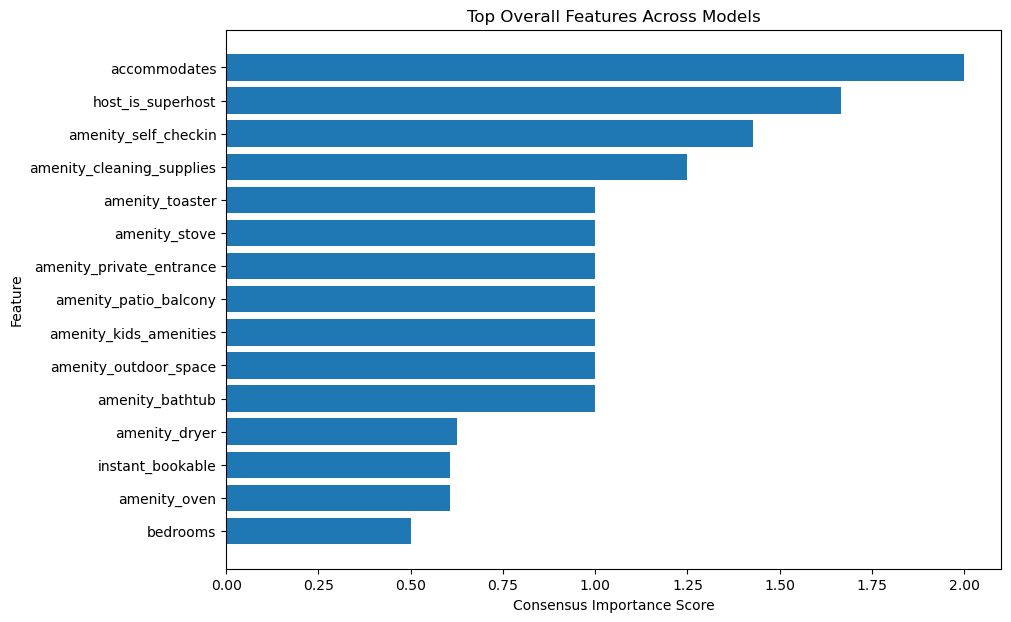

In [57]:
# Create a copy of the feature rank matrix
overall_feature_rankings = rank_matrix_plot.copy()

# Count how many models included each feature in their top features
overall_feature_rankings['model_count'] = overall_feature_rankings.notna().sum(axis=1)

# Calculate average rank across models
# Lower average rank = more consistently important
overall_feature_rankings['average_rank'] = overall_feature_rankings.mean(axis=1)

# Create a consensus score
# Features get a stronger score if they rank highly and appear in multiple models
overall_feature_rankings['consensus_score'] = (
    overall_feature_rankings['model_count'] / overall_feature_rankings['average_rank']
)

# Sort features by consensus score
overall_feature_rankings = overall_feature_rankings.sort_values(
    by='consensus_score',
    ascending=False)

# Select top 15 overall features
top_overall_features = overall_feature_rankings.head(15).reset_index()

# Plot top overall features
plt.figure(figsize=(10, 7))

plt.barh(
    top_overall_features['feature'],
    top_overall_features['consensus_score']
)

# Put strongest overall feature at the top
plt.gca().invert_yaxis()

# Add labels and title
plt.title('Top Overall Features Across Models')
plt.xlabel('Consensus Importance Score')
plt.ylabel('Feature')

# Display plot
plt.show()

# Stakeholder Summary

The final model predicts log-transformed reviews per month, which is being used as a proxy for Airbnb listing demand.

The strongest model was selected based on prediction error, cross-validation performance, and interpretability.

Overall, the results suggest that demand is influenced by a combination of listing capacity, location, review quality, host/listing characteristics, and selected amenities.

From a business perspective, this model can help identify which types of listings are more likely to perform well and which features may be associated with stronger guest engagement.

## Optional Business Classification: High-Demand vs. Low-Demand Listings

## Classification


In [ ]:
# Create binary high/low demand target
df['high_demand'] = (df['reviews_per_month'] > df['reviews_per_month'].median()).astype(int)

y_class = df['high_demand']

In [ ]:
accuracy_score
precision_score
recall_score
f1_score
confusion_matrix

## Analysis:
* Core features like location, bedrooms, and bathrooms explain most of the pricing
* Amenities did improve the model performance and explained variance.

## Rare Amenity Analysis (Exploratory)


In [ ]:
df

In [ ]:
df.shape

In [ ]:
df.groupby('amenity_ski_access')['price'].mean()

In [ ]:
df.groupby('amenity_ski_access')['reviews_per_month'].mean()